# 03. Target Label & Baseline Error Analysis
This notebook analyzes the relationship between historical trajectories and the actual target labels (`train_labels.csv`). We evaluate simple physics-based baselines (Constant Velocity/Acceleration) to establish a performance floor.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
from tqdm.auto import tqdm

DATA_DIR = '../data/open/train/'
LABEL_PATH = '../data/open/train_labels.csv'
DT = 0.040
TARGET_DT = 0.400

sns.set_theme(style='whitegrid')

c:\Repo\dacon-mosquito-trajectory\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load History and Labels

In [2]:
labels = pd.read_csv(LABEL_PATH)
def load_history_tail(file_list, limit=2000):
    history_data = []
    for f in tqdm(file_list[:limit]):
        df = pd.read_csv(f)
        id_val = os.path.basename(f).split('.')[0]
        tail = df.tail(3).copy()
        tail['id'] = id_val # Use lowercase 'id' for consistency
        history_data.append(tail)
    return pd.concat(history_data, ignore_index=True)

train_files = sorted(glob(os.path.join(DATA_DIR, '*.csv')))
df_tail = load_history_tail(train_files, limit=2000)

100%|██████████| 2000/2000 [00:01<00:00, 1084.26it/s]


## 2. Baseline Calculation (CV & CA)

In [3]:
def calculate_baselines(df_tail, labels, target_lag=0.400):
    results = []
    ids = df_tail['id'].unique()
    
    for id_val in tqdm(ids):
        # Only select coordinate columns for float conversion
        group = df_tail[df_tail['id'] == id_val][['x', 'y', 'z']].astype(float)
        
        # Last point (t=0)
        p0 = group.iloc[-1].values
        # Velocity at t=0 (last delta)
        v0 = (group.iloc[-1].values - group.iloc[-2].values) / DT
        # Acceleration at t=0
        v_prev = (group.iloc[-2].values - group.iloc[-3].values) / DT
        a0 = (v0 - v_prev) / DT
        
        # Actual Target (using lowercase 'id')
        target_row = labels[labels['id'] == id_val]
        if target_row.empty: continue
        target = target_row[['x', 'y', 'z']].values.flatten().astype(float)
        
        # Constant Velocity Prediction
        p_cv = p0 + v0 * target_lag
        # Constant Acceleration Prediction
        p_ca = p0 + v0 * target_lag + 0.5 * a0 * (target_lag**2)
        
        results.append({
            'id': id_val,
            'error_cv': np.sum((p_cv - target)**2)**0.5,
            'error_ca': np.sum((p_ca - target)**2)**0.5,
            'dist_to_target': np.sum((target - p0)**2)**0.5
        })
    return pd.DataFrame(results)

df_results = calculate_baselines(df_tail, labels)

100%|██████████| 2000/2000 [00:04<00:00, 442.85it/s]


## 3. Error Distribution

Mean CV Error: 0.2095m
Mean CA Error: 0.3844m


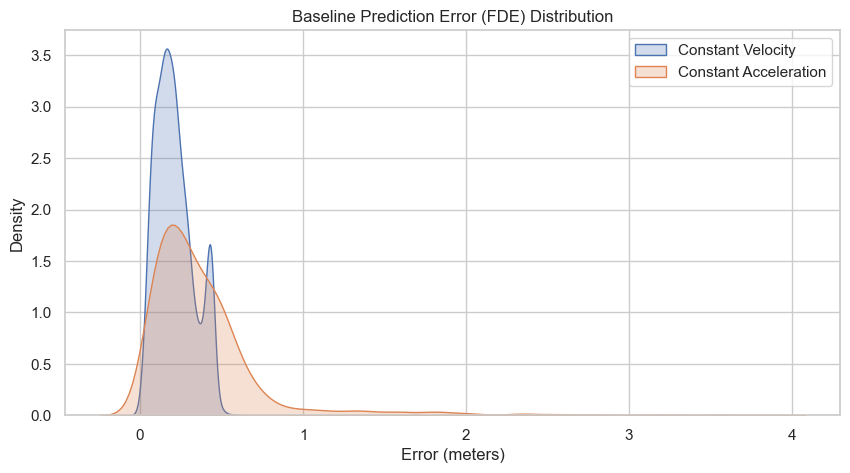

In [4]:
if not df_results.empty:
    print(f"Mean CV Error: {df_results['error_cv'].mean():.4f}m")
    print(f"Mean CA Error: {df_results['error_ca'].mean():.4f}m")

    plt.figure(figsize=(10, 5))
    sns.kdeplot(df_results['error_cv'], label='Constant Velocity', fill=True)
    sns.kdeplot(df_results['error_ca'], label='Constant Acceleration', fill=True)
    plt.title("Baseline Prediction Error (FDE) Distribution")
    plt.xlabel("Error (meters)")
    plt.legend()
    plt.show()

## 4. Analysis: When do Baselines fail?

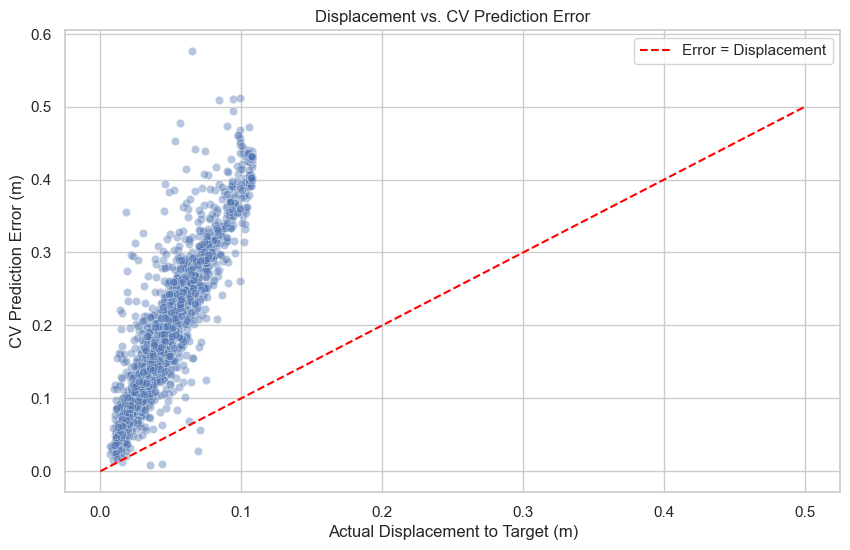

In [5]:
if not df_results.empty:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_results, x='dist_to_target', y='error_cv', alpha=0.4)
    plt.plot([0, 0.5], [0, 0.5], color='red', linestyle='--', label='Error = Displacement')
    plt.title("Displacement vs. CV Prediction Error")
    plt.xlabel("Actual Displacement to Target (m)")
    plt.ylabel("CV Prediction Error (m)")
    plt.legend()
    plt.show()